In [139]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import sklearn.datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Iris Dataset Overview

---
| Iris setosa | Iris versicolor | Iris virginica |
| :---: | :---: | :---: |
| <img src="https://upload.wikimedia.org/wikipedia/commons/a/a7/Irissetosa1.jpg?utm_source=en.wikipedia.org&utm_campaign=index&utm_content=original" width="200" alt="Iris setosa"> | <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" width="200" alt="Iris versicolor"> | <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" width="200" alt="Iris virginica"> |

In [140]:
dados = sklearn.datasets.load_iris()

print("Atributos:", dados['feature_names'])
print("Classes (labels):", dados['target_names'])
print("Dimensões:", dados['data'].shape)
df = pd.DataFrame(dados.data, columns=dados.feature_names)
df['label'] = [dados.target_names[i] for i in dados.target]

Atributos: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes (labels): ['setosa' 'versicolor' 'virginica']
Dimensões: (150, 4)


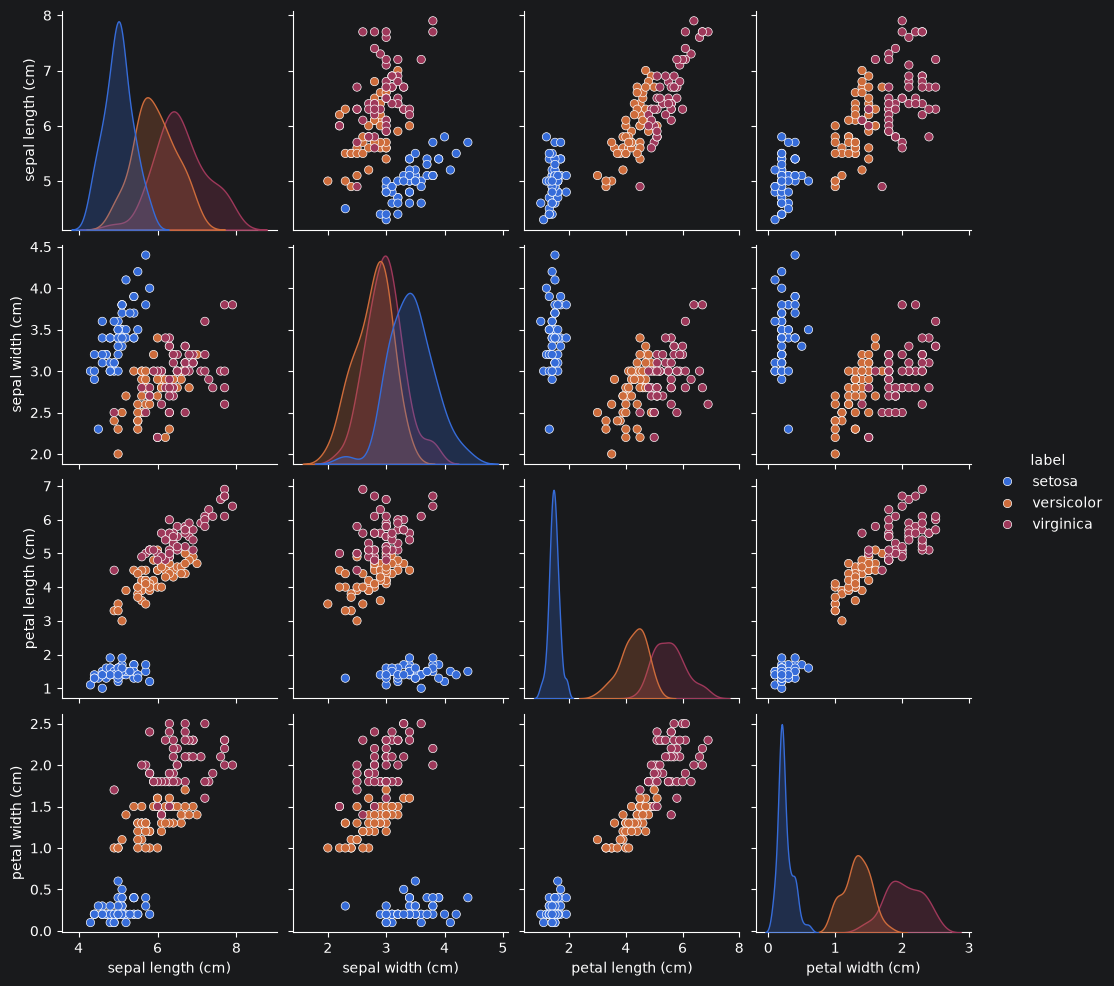

In [141]:
# Pair Plot
sns.pairplot(df, hue='label')

In [142]:
X = df.drop(['label'], axis=1)
# Normalização dos dados (Min-Max)
normalizador = MinMaxScaler()
X_norm = pd.DataFrame(normalizador.fit_transform(X), columns=X.columns)
labels = df.label.unique()
print(labels)

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


In [143]:
#Transformação dos atributos (classes) categóricos em
# numéricos (1-de-c / one-hot-encoding)
# setosa -> 0 0 1
# versicolor -> 0 1 0
# virginica -> 1 0 0
Y = pd.get_dummies(df.label)
print(Y)

     setosa  versicolor  virginica
0      True       False      False
1      True       False      False
2      True       False      False
3      True       False      False
4      True       False      False
..      ...         ...        ...
145   False       False       True
146   False       False       True
147   False       False       True
148   False       False       True
149   False       False       True

[150 rows x 3 columns]


In [144]:
# Separação desenvolvimento (90) e teste (10)
X_dev, X_test, Y_dev, Y_test = train_test_split(X_norm, Y, test_size=0.1, random_state=1)
# Separação treino (80) e validação (20)
X_train, X_val, Y_train, Y_val = train_test_split(X_dev, Y_dev, test_size=0.2, random_state=1)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(108, 4)
(27, 4)
(15, 4)


In [145]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.Tanh(),
            nn.Linear(10, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out = self.rede(x)
        return out

In [146]:
input_dim = 4  # número de atributos do Iris
output_dim = 3  # número de classes
modelo = MLP(input_dim, output_dim)  # Criação do modelo (rede)

print(modelo)

MLP(
  (rede): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=3, bias=True)
    (3): Sigmoid()
  )
)


In [147]:
device = "cuda" if torch.cuda.is_available() else "cpu"
modelo.to(device)
print(device)

cuda


In [148]:
summary(modelo, (150, 4), device=device)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 150, 10]              50
              Tanh-2              [-1, 150, 10]               0
            Linear-3               [-1, 150, 3]              33
           Sigmoid-4               [-1, 150, 3]               0
Total params: 83
Trainable params: 83
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.00
Estimated Total Size (MB): 0.03
----------------------------------------------------------------


In [149]:
eta = 0.2
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=eta)

In [150]:
x_train = torch.FloatTensor(X_train.values).to(device)
y_train = torch.FloatTensor(Y_train.values).to(device)

x_val = torch.FloatTensor(X_val.values).to(device)
y_val = torch.FloatTensor(Y_val.values).to(device)

x_test = torch.FloatTensor(X_test.values).to(device)
y_test = torch.FloatTensor(Y_test.values).to(device)

In [151]:
def train_network(model, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses,
                  val_losses):
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        output_train = model(x_train)
        loss_train = loss_function(output_train, y_train)
        loss_train.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            output_val = model(x_val)
            loss_val = loss_function(output_val, y_val)

        train_losses[epoch] = loss_train.item()
        val_losses[epoch] = loss_val.item()

        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, "
                f"Train Loss: {loss_train.item():.4f}, "
                f"Val Loss: {loss_val.item():.4f}"
            )

In [152]:
num_epochs = 5000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(modelo, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch 100/5000, Train Loss: 0.1848, Val Loss: 0.1964
Epoch 200/5000, Train Loss: 0.1515, Val Loss: 0.1589
Epoch 300/5000, Train Loss: 0.1299, Val Loss: 0.1315
Epoch 400/5000, Train Loss: 0.1187, Val Loss: 0.1171
Epoch 500/5000, Train Loss: 0.1122, Val Loss: 0.1086
Epoch 600/5000, Train Loss: 0.1075, Val Loss: 0.1027
Epoch 700/5000, Train Loss: 0.1038, Val Loss: 0.0982
Epoch 800/5000, Train Loss: 0.1004, Val Loss: 0.0943
Epoch 900/5000, Train Loss: 0.0972, Val Loss: 0.0907
Epoch 1000/5000, Train Loss: 0.0941, Val Loss: 0.0873
Epoch 1100/5000, Train Loss: 0.0910, Val Loss: 0.0839
Epoch 1200/5000, Train Loss: 0.0878, Val Loss: 0.0805
Epoch 1300/5000, Train Loss: 0.0845, Val Loss: 0.0770
Epoch 1400/5000, Train Loss: 0.0811, Val Loss: 0.0734
Epoch 1500/5000, Train Loss: 0.0775, Val Loss: 0.0698
Epoch 1600/5000, Train Loss: 0.0739, Val Loss: 0.0660
Epoch 1700/5000, Train Loss: 0.0703, Val Loss: 0.0622
Epoch 1800/5000, Train Loss: 0.0667, Val Loss: 0.0585
Epoch 1900/5000, Train Loss: 0.0632, 

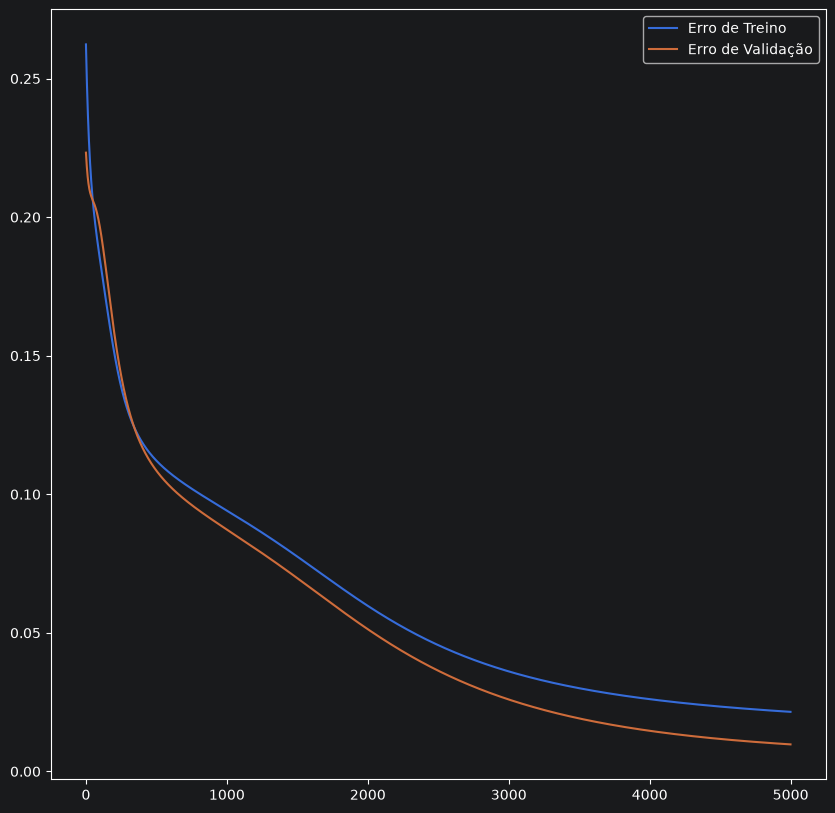

In [153]:
plt.figure(figsize=(10, 10))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.legend()
plt.show()

In [154]:
predictions_train = []
predictions_val = []
predictions_test = []
with torch.no_grad():
    predictions_train = modelo(x_train)
    predictions_val = modelo(x_val)
    predictions_test = modelo(x_test)

In [155]:
# Cálculo do erro (Função de Custo)
erro_train = loss_function(predictions_train, y_train)
erro_val = loss_function(predictions_val, y_val)
erro_test = loss_function(predictions_test, y_test)
print(f"Erro de Treino: {erro_train}")
print(f"Erro de Validação: {erro_val}")
print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.02148699201643467
Erro de Validação: 0.009747426025569439
Erro de Teste: 0.009198986925184727


In [156]:
# Cálculo da Acurácia de Classificação:
import torch
from sklearn.metrics import accuracy_score

# Get predictions and targets
pred_train = torch.argmax(predictions_train, dim=1)
label_train = torch.argmax(y_train, dim=1)

pred_val = torch.argmax(predictions_val, dim=1)
label_val = torch.argmax(y_val, dim=1)

pred_test = torch.argmax(predictions_test, dim=1)
label_test = torch.argmax(y_test, dim=1)

# Calculate accuracy on CPU
acc_train = accuracy_score(label_train.cpu(), pred_train.cpu())
acc_val = accuracy_score(label_val.cpu(), pred_val.cpu())
acc_test = accuracy_score(label_test.cpu(), pred_test.cpu())

print(f"Train Accuracy: {acc_train * 100:.2f}%")
print(f"Validation Accuracy: {acc_val * 100:.2f}%")
print(f"Test Accuracy: {acc_test * 100:.2f}%")

Train Accuracy: 96.30%
Validation Accuracy: 100.00%
Test Accuracy: 100.00%


# Problema XOR

In [157]:
# torch.manual_seed(7) # aprende as portas Not-AND e Not-OR
torch.manual_seed(9)


class MLPXor(nn.Module):
    def __init__(self):
        super(MLPXor, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        hidden = self.hidden(x)
        x1 = torch.sigmoid(hidden)
        output = self.output(x1)
        x2 = torch.sigmoid(output)
        return x2, x1

In [166]:
modeloXOR = MLPXor().to(device)  # Criação do modelo (rede)

In [167]:
loss_function = nn.MSELoss()
# optimizer = torch.optim.Adam(modeloXOR.parameters(),lr=eta)
optimizer = torch.optim.SGD(modeloXOR.parameters(), lr=0.02, momentum=0.9)

In [171]:
x_xor = torch.Tensor([[0, 0], [0, 1], [1, 0], [1, 1]]).to(device)
y_xor = torch.Tensor([0, 1, 1, 0]).view(-1, 1).to(device)
print(x_xor)
print(y_xor)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], device='cuda:0')
tensor([[0.],
        [1.],
        [1.],
        [0.]], device='cuda:0')


In [169]:
def train_xor(model, optimizer, loss_function, x_train, y_train, num_epochs, train_losses):
    for epoch in range(num_epochs):
        for _ in range(4):
            exemplo = np.random.randint(4)
            x = x_train[exemplo]
            y = y_train[exemplo]

            optimizer.zero_grad()
            y_hat, _ = model(x)
            loss_train = loss_function(y_hat, y)
            loss_train.backward()
            optimizer.step()

        train_losses[epoch] = loss_train.item()

        if (epoch + 1) % 1000 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}"
            )

In [173]:
num_epochs = 5000
train_losses = np.zeros(num_epochs)
train_xor(modeloXOR, optimizer, loss_function, x_xor, y_xor, num_epochs, train_losses)

Epoch 1000/5000, Erro Treino: 0.0008
Epoch 2000/5000, Erro Treino: 0.0006
Epoch 3000/5000, Erro Treino: 0.0005
Epoch 4000/5000, Erro Treino: 0.0004
Epoch 5000/5000, Erro Treino: 0.0004


In [174]:
predictions, hidden = modeloXOR(x_xor)
pred = predictions > 0.5
hid = hidden > 0.5
print(x_xor)
print(predictions)
print(hidden)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], device='cuda:0')
tensor([[0.0225],
        [0.9805],
        [0.9805],
        [0.0201]], device='cuda:0', grad_fn=<SigmoidBackward0>)
tensor([[3.6425e-02, 4.1834e-02],
        [9.3011e-01, 1.2648e-04],
        [9.2394e-05, 9.2350e-01],
        [3.1506e-02, 3.3795e-02]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [175]:
print("Saídas do modelo: ")
print(pred)
print("Saídas das Camadas Ocultas: ")
print(hid)

Saídas do modelo: 
tensor([[False],
        [ True],
        [ True],
        [False]], device='cuda:0')
Saídas das Camadas Ocultas: 
tensor([[False, False],
        [ True, False],
        [False,  True],
        [False, False]], device='cuda:0')
